In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[0:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [7]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:3]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join([itos[i] for i in context]), '---->', itos[ix])
        context = context[1:] + [ix] # crop and append

X= torch.tensor(X)
Y = torch.tensor(Y)


emma
... ----> e
..e ----> m
.em ----> m
emm ----> a
mma ----> .
olivia
... ----> o
..o ----> l
.ol ----> i
oli ----> v
liv ----> i
ivi ----> a
via ----> .
ava
... ----> a
..a ----> v
.av ----> a
ava ----> .


In [8]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([16, 3]), torch.int64, torch.Size([16]), torch.int64)

In [9]:
C = torch.randn((27, 2)) # character embedding table

In [10]:
C

tensor([[-0.1513,  1.7446],
        [ 0.8143,  0.5040],
        [-1.1584, -1.6509],
        [-1.3067, -0.5943],
        [-0.6727,  0.1754],
        [ 0.8681, -0.5578],
        [-0.0770,  0.7687],
        [ 1.5573, -0.8547],
        [ 1.2530, -0.0066],
        [-0.1069,  1.6608],
        [-0.6570, -1.9663],
        [-0.3052,  0.8663],
        [ 0.9572, -0.4478],
        [-2.0173,  2.1001],
        [-1.3170, -0.2074],
        [-1.7357,  0.5240],
        [ 0.7871,  0.8492],
        [-0.8705, -0.9911],
        [-0.1430, -0.7423],
        [-0.6757, -0.2775],
        [ 0.3252,  0.4136],
        [-0.8739, -0.6098],
        [-0.5472,  2.1020],
        [-1.2167,  0.8369],
        [ 1.2574,  0.2055],
        [ 0.7448,  0.4397],
        [-2.2749,  0.5231]])

In [11]:
C[5]

tensor([ 0.8681, -0.5578])

In [13]:
C[torch.tensor([1, 2, 3, 4 ])]

tensor([[ 0.8143,  0.5040],
        [-1.1584, -1.6509],
        [-1.3067, -0.5943],
        [-0.6727,  0.1754]])

In [16]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1]])

In [ ]:
C[X]

tensor([[[-0.1513,  1.7446],
         [-0.1513,  1.7446],
         [-0.1513,  1.7446]],

        [[-0.1513,  1.7446],
         [-0.1513,  1.7446],
         [ 0.8681, -0.5578]],

        [[-0.1513,  1.7446],
         [ 0.8681, -0.5578],
         [-2.0173,  2.1001]],

        [[ 0.8681, -0.5578],
         [-2.0173,  2.1001],
         [-2.0173,  2.1001]],

        [[-2.0173,  2.1001],
         [-2.0173,  2.1001],
         [ 0.8143,  0.5040]],

        [[-0.1513,  1.7446],
         [-0.1513,  1.7446],
         [-0.1513,  1.7446]],

        [[-0.1513,  1.7446],
         [-0.1513,  1.7446],
         [-1.7357,  0.5240]],

        [[-0.1513,  1.7446],
         [-1.7357,  0.5240],
         [ 0.9572, -0.4478]],

        [[-1.7357,  0.5240],
         [ 0.9572, -0.4478],
         [-0.1069,  1.6608]],

        [[ 0.9572, -0.4478],
         [-0.1069,  1.6608],
         [-0.5472,  2.1020]],

        [[-0.1069,  1.6608],
         [-0.5472,  2.1020],
         [-0.1069,  1.6608]],

        [[-0.5472,  2

In [17]:
C[X].shape

torch.Size([16, 3, 2])

In [18]:
emb = C[X]
emb.shape

torch.Size([16, 3, 2])

In [19]:
W1 = torch.randn((6, 100)) # 6 inputs, 100 outputs
b1 = torch.randn(100) # 100 outputs

In [22]:
emb[:, 0, :], emb[:, 1, :],emb[:, 2, :]

(tensor([[-0.1513,  1.7446],
         [-0.1513,  1.7446],
         [-0.1513,  1.7446],
         [ 0.8681, -0.5578],
         [-2.0173,  2.1001],
         [-0.1513,  1.7446],
         [-0.1513,  1.7446],
         [-0.1513,  1.7446],
         [-1.7357,  0.5240],
         [ 0.9572, -0.4478],
         [-0.1069,  1.6608],
         [-0.5472,  2.1020],
         [-0.1513,  1.7446],
         [-0.1513,  1.7446],
         [-0.1513,  1.7446],
         [ 0.8143,  0.5040]]),
 tensor([[-0.1513,  1.7446],
         [-0.1513,  1.7446],
         [ 0.8681, -0.5578],
         [-2.0173,  2.1001],
         [-2.0173,  2.1001],
         [-0.1513,  1.7446],
         [-0.1513,  1.7446],
         [-1.7357,  0.5240],
         [ 0.9572, -0.4478],
         [-0.1069,  1.6608],
         [-0.5472,  2.1020],
         [-0.1069,  1.6608],
         [-0.1513,  1.7446],
         [-0.1513,  1.7446],
         [ 0.8143,  0.5040],
         [-0.5472,  2.1020]]),
 tensor([[-0.1513,  1.7446],
         [ 0.8681, -0.5578],
         [

In [24]:
torch.cat([emb[:, 0, :], emb[:, 1, :],emb[:, 2, :]], dim=1)

tensor([[-0.1513,  1.7446, -0.1513,  1.7446, -0.1513,  1.7446],
        [-0.1513,  1.7446, -0.1513,  1.7446,  0.8681, -0.5578],
        [-0.1513,  1.7446,  0.8681, -0.5578, -2.0173,  2.1001],
        [ 0.8681, -0.5578, -2.0173,  2.1001, -2.0173,  2.1001],
        [-2.0173,  2.1001, -2.0173,  2.1001,  0.8143,  0.5040],
        [-0.1513,  1.7446, -0.1513,  1.7446, -0.1513,  1.7446],
        [-0.1513,  1.7446, -0.1513,  1.7446, -1.7357,  0.5240],
        [-0.1513,  1.7446, -1.7357,  0.5240,  0.9572, -0.4478],
        [-1.7357,  0.5240,  0.9572, -0.4478, -0.1069,  1.6608],
        [ 0.9572, -0.4478, -0.1069,  1.6608, -0.5472,  2.1020],
        [-0.1069,  1.6608, -0.5472,  2.1020, -0.1069,  1.6608],
        [-0.5472,  2.1020, -0.1069,  1.6608,  0.8143,  0.5040],
        [-0.1513,  1.7446, -0.1513,  1.7446, -0.1513,  1.7446],
        [-0.1513,  1.7446, -0.1513,  1.7446,  0.8143,  0.5040],
        [-0.1513,  1.7446,  0.8143,  0.5040, -0.5472,  2.1020],
        [ 0.8143,  0.5040, -0.5472,  2.1

In [25]:
torch.cat(torch.unbind(emb, dim=1), dim=1) # unbind splits the tensor into a list of tensors along the given dimension

tensor([[-0.1513,  1.7446, -0.1513,  1.7446, -0.1513,  1.7446],
        [-0.1513,  1.7446, -0.1513,  1.7446,  0.8681, -0.5578],
        [-0.1513,  1.7446,  0.8681, -0.5578, -2.0173,  2.1001],
        [ 0.8681, -0.5578, -2.0173,  2.1001, -2.0173,  2.1001],
        [-2.0173,  2.1001, -2.0173,  2.1001,  0.8143,  0.5040],
        [-0.1513,  1.7446, -0.1513,  1.7446, -0.1513,  1.7446],
        [-0.1513,  1.7446, -0.1513,  1.7446, -1.7357,  0.5240],
        [-0.1513,  1.7446, -1.7357,  0.5240,  0.9572, -0.4478],
        [-1.7357,  0.5240,  0.9572, -0.4478, -0.1069,  1.6608],
        [ 0.9572, -0.4478, -0.1069,  1.6608, -0.5472,  2.1020],
        [-0.1069,  1.6608, -0.5472,  2.1020, -0.1069,  1.6608],
        [-0.5472,  2.1020, -0.1069,  1.6608,  0.8143,  0.5040],
        [-0.1513,  1.7446, -0.1513,  1.7446, -0.1513,  1.7446],
        [-0.1513,  1.7446, -0.1513,  1.7446,  0.8143,  0.5040],
        [-0.1513,  1.7446,  0.8143,  0.5040, -0.5472,  2.1020],
        [ 0.8143,  0.5040, -0.5472,  2.1

In [26]:
a = torch.arange(12)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [27]:
a.view(3, 4)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

In [30]:
emb.view(16, 6)

tensor([[-0.1513,  1.7446, -0.1513,  1.7446, -0.1513,  1.7446],
        [-0.1513,  1.7446, -0.1513,  1.7446,  0.8681, -0.5578],
        [-0.1513,  1.7446,  0.8681, -0.5578, -2.0173,  2.1001],
        [ 0.8681, -0.5578, -2.0173,  2.1001, -2.0173,  2.1001],
        [-2.0173,  2.1001, -2.0173,  2.1001,  0.8143,  0.5040],
        [-0.1513,  1.7446, -0.1513,  1.7446, -0.1513,  1.7446],
        [-0.1513,  1.7446, -0.1513,  1.7446, -1.7357,  0.5240],
        [-0.1513,  1.7446, -1.7357,  0.5240,  0.9572, -0.4478],
        [-1.7357,  0.5240,  0.9572, -0.4478, -0.1069,  1.6608],
        [ 0.9572, -0.4478, -0.1069,  1.6608, -0.5472,  2.1020],
        [-0.1069,  1.6608, -0.5472,  2.1020, -0.1069,  1.6608],
        [-0.5472,  2.1020, -0.1069,  1.6608,  0.8143,  0.5040],
        [-0.1513,  1.7446, -0.1513,  1.7446, -0.1513,  1.7446],
        [-0.1513,  1.7446, -0.1513,  1.7446,  0.8143,  0.5040],
        [-0.1513,  1.7446,  0.8143,  0.5040, -0.5472,  2.1020],
        [ 0.8143,  0.5040, -0.5472,  2.1

In [31]:
emb.view(-1, 6)

tensor([[-0.1513,  1.7446, -0.1513,  1.7446, -0.1513,  1.7446],
        [-0.1513,  1.7446, -0.1513,  1.7446,  0.8681, -0.5578],
        [-0.1513,  1.7446,  0.8681, -0.5578, -2.0173,  2.1001],
        [ 0.8681, -0.5578, -2.0173,  2.1001, -2.0173,  2.1001],
        [-2.0173,  2.1001, -2.0173,  2.1001,  0.8143,  0.5040],
        [-0.1513,  1.7446, -0.1513,  1.7446, -0.1513,  1.7446],
        [-0.1513,  1.7446, -0.1513,  1.7446, -1.7357,  0.5240],
        [-0.1513,  1.7446, -1.7357,  0.5240,  0.9572, -0.4478],
        [-1.7357,  0.5240,  0.9572, -0.4478, -0.1069,  1.6608],
        [ 0.9572, -0.4478, -0.1069,  1.6608, -0.5472,  2.1020],
        [-0.1069,  1.6608, -0.5472,  2.1020, -0.1069,  1.6608],
        [-0.5472,  2.1020, -0.1069,  1.6608,  0.8143,  0.5040],
        [-0.1513,  1.7446, -0.1513,  1.7446, -0.1513,  1.7446],
        [-0.1513,  1.7446, -0.1513,  1.7446,  0.8143,  0.5040],
        [-0.1513,  1.7446,  0.8143,  0.5040, -0.5472,  2.1020],
        [ 0.8143,  0.5040, -0.5472,  2.1

In [32]:
h = emb.view(-1, 6) @ W1 + b1 # (batch, 6) @ (6, 100) + (100,) --> (batch, 100)


In [33]:
h

tensor([[-6.7258e+00,  2.8316e-01, -1.9217e+00,  ...,  3.8319e+00,
         -5.4963e-01, -8.9466e-02],
        [-5.0657e+00, -4.6475e+00, -1.0046e+00,  ...,  2.2708e+00,
          7.7349e-01,  6.4310e-01],
        [-3.7220e+00,  2.2081e+00, -3.2271e+00,  ..., -5.0480e+00,
         -2.8313e+00,  3.0553e-01],
        ...,
        [-5.9136e+00, -2.5602e+00, -1.2955e+00,  ...,  3.9131e+00,
          1.7084e-01, -3.9083e-02],
        [-5.4575e+00,  1.5380e+00, -3.1909e+00,  ...,  4.6914e-03,
         -2.5973e+00, -1.1210e+00],
        [-4.3079e+00, -1.0428e+00, -8.2225e-01,  ...,  5.6578e+00,
          8.3863e-01, -1.6945e+00]])

In [34]:
h = torch.tanh(h) # nonlinearity
h

tensor([[-1.0000,  0.2758, -0.9581,  ...,  0.9991, -0.5002, -0.0892],
        [-0.9999, -0.9998, -0.7635,  ...,  0.9789,  0.6490,  0.5670],
        [-0.9988,  0.9761, -0.9969,  ..., -0.9999, -0.9931,  0.2964],
        ...,
        [-1.0000, -0.9881, -0.8606,  ...,  0.9992,  0.1692, -0.0391],
        [-1.0000,  0.9118, -0.9966,  ...,  0.0047, -0.9890, -0.8079],
        [-0.9996, -0.7790, -0.6763,  ...,  1.0000,  0.6851, -0.9347]])

In [35]:
h.shape

torch.Size([16, 100])

In [36]:
W2 = torch.randn((100, 27)) # 100 inputs, 27 outputs 
b2 = torch.randn(27) # 27 outputs
 

In [37]:
logits = h @ W2 + b2 # (batch, 100) @ (100, 27) + (27,) --> (batch, 27)

In [38]:
logits.shape

torch.Size([16, 27])

In [39]:
counts = logits.exp() # counts

In [40]:
prob = counts / counts.sum(1, keepdim=True) # probabilities for next character

In [41]:
prob

tensor([[1.0273e-09, 2.2590e-14, 1.9340e-05, 8.4820e-06, 4.0497e-11, 5.1177e-08,
         9.4461e-09, 7.1577e-14, 4.8884e-11, 2.2411e-16, 8.1596e-01, 1.5889e-12,
         1.5010e-09, 8.4634e-09, 8.8294e-07, 4.4356e-12, 3.3253e-05, 2.1336e-03,
         4.8586e-13, 1.7664e-11, 9.2430e-12, 1.4832e-03, 2.4441e-07, 1.8036e-01,
         7.4062e-13, 6.4286e-07, 2.5437e-09],
        [1.1275e-10, 2.0359e-13, 1.8715e-08, 9.8869e-03, 1.1601e-11, 2.9085e-11,
         4.9040e-07, 7.9735e-15, 3.0161e-08, 3.4677e-16, 5.7430e-04, 6.6707e-06,
         3.8265e-12, 3.5739e-09, 3.5647e-08, 4.3108e-11, 2.3555e-06, 9.3581e-01,
         3.7005e-11, 6.9953e-05, 2.9455e-13, 5.1942e-02, 4.3425e-07, 1.7078e-03,
         2.0435e-11, 2.9259e-15, 8.9408e-12],
        [1.9979e-05, 2.2978e-12, 9.5631e-01, 5.4743e-12, 1.6563e-11, 3.6122e-04,
         1.9713e-09, 8.6206e-08, 1.4768e-10, 6.6375e-11, 4.8813e-04, 3.1022e-12,
         2.4658e-05, 2.0860e-07, 3.5653e-04, 1.0121e-06, 1.3412e-08, 7.6928e-13,
         2.4630e-

In [43]:
torch.arange(16)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

In [44]:
prob[torch.arange(16), Y]

tensor([5.1177e-08, 3.5739e-09, 2.0860e-07, 1.4947e-09, 5.2304e-12, 4.4356e-12,
        1.9150e-16, 8.3224e-10, 4.9928e-10, 3.5311e-12, 1.6901e-14, 7.3422e-13,
        2.2590e-14, 1.1981e-07, 2.1862e-12, 9.0640e-12])

In [45]:
loss = -prob[torch.arange(16), Y].log().mean()
loss

tensor(24.2644)

In [66]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [67]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [70]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [71]:
for p in parameters:
    p.requires_grad = True

In [72]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [73]:
lri = []
lossi = []
stepi = []

In [74]:
for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

In [75]:
print(loss.item())

1.9068344831466675


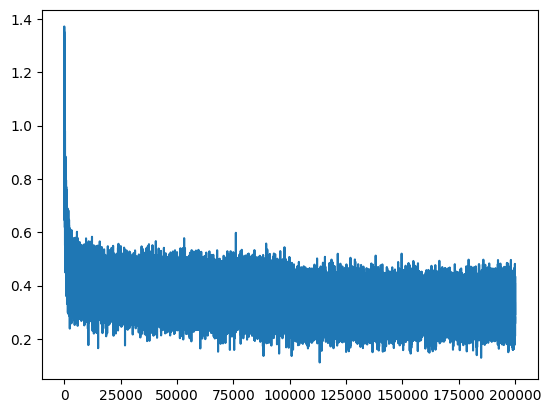

In [76]:
plt.plot(stepi, lossi)

In [77]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1447, grad_fn=<NllLossBackward0>)

In [78]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1852, grad_fn=<NllLossBackward0>)

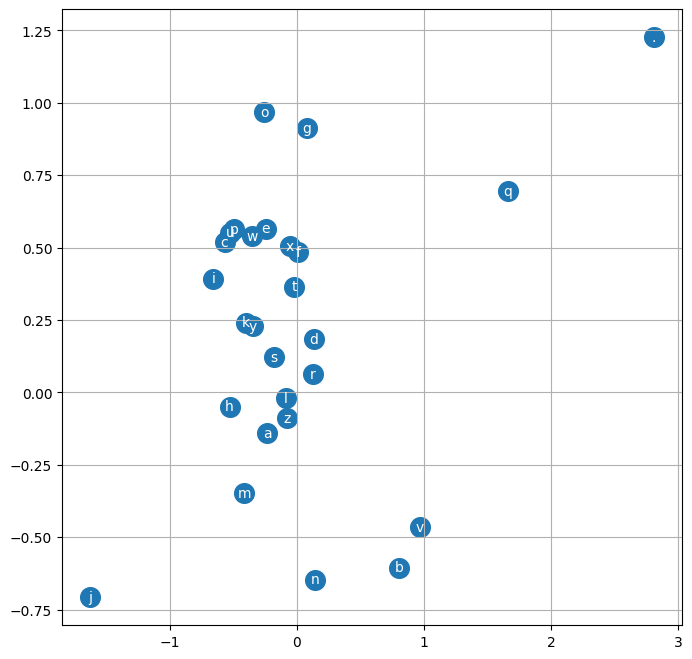

In [79]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [80]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [81]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carlah.
amelle.
khi.
myli.
thold.
kanden.
jazheen.
den.
rha.
kaqui.
ner.
kip.
chaiim.
kaleigh.
ham.
pore.
quinn.
sulinea.
jamique.
jerogiearyni.
